<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%207%20-%20Cameron's%20Version/regime%201%20-%20CIFAR-10/CIFAR-10%20-%2008_vq_latent_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 7 — VQ-latent diffusion (CIFAR-10)
**Training a VQ-VAE through its non-differentiable codebook.** A VQ-VAE encodes each image into discrete codes via a nearest-neighbour `argmin` over a codebook — a genuinely non-differentiable channel. Standard VQ-VAE only trains the encoder through it by using the **straight-through estimator (STE)** hack. Here we compare three ways to send the encoder's learning signal across that channel, at equal steps, with an identical (backprop) decoder and (EMA) codebook — so the *only* difference is how the encoder crosses the `argmin`.

## The three encoder routes
- **backprop + STE** — the standard VQ-VAE trick: pretend the quantizer is the identity on the backward pass. Works, but it's a biased surrogate gradient.
- **backprop, no STE** — the honest backward pass through `argmin`: the encoder gradient is *exactly zero* (a step function's derivative). The encoder never moves; only the decoder + codebook learn.
- **local three-factor** — the antithetic zeroth-order probe rule from the rest of the paper, applied to the encoder. It never differentiates the channel — it only *evaluates* the (post-quantization) loss at `θ ± σξ`. It trains the encoder through the exact hard `argmin`, no relaxation.

The decoder is downstream of the channel and fully differentiable, so it uses backprop for every method; the codebook uses gradient-free EMA for every method. This isolates the comparison to the channel.

In [1]:
# Setup
import os, math, time, json
import torch, torch.nn as nn, torch.nn.functional as F
from torch.func import functional_call, vmap
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0)
print('device:', device)

device: cuda


In [2]:
# Config  (SMOKE=True gives a tiny CPU sanity run; set SMOKE=False for the real A100 run)
SMOKE = False
CORRUPT_SIGMA = 0.0      # 0.0 = autoencoder, 0.5 = denoiser (noisy input -> clean target)
INCLUDE_DDPM  = True   # train a latent DDPM on the VQ codes and sample CIFAR images from noise

# VQ-VAE size (encoder P drives the local rule's cost ~ P^2, so keep the encoder modest)
D, K, HIDDEN = 16, 256, 48        # latent dim, codebook size (more codes for color), conv width
# training budget (all three encoder-routes run for the SAME number of steps -> fair learning curves)
N_STEPS   = 800
BATCH     = 128
EVAL_EVERY= 25
# backprop routes
LR_BP, DEC_LR, BETA = 2e-3, 2e-3, 0.25
# local three-factor route (encoder only; decoder is backprop, codebook is EMA -- shared by all)
M_PROBES, SIGMA, LR_LOCAL, MOM = 48, 0.05, 0.05, 0.9
# latent DDPM
DDPM_T, DDPM_STEPS, DDPM_HID = 100, 2000, 64

if SMOKE:
    D, K, HIDDEN = 8, 32, 16
    N_STEPS, BATCH, EVAL_EVERY, M_PROBES = 12, 64, 4, 8
    DDPM_T, DDPM_STEPS, DDPM_HID = 20, 12, 16
print(f'VQ-VAE D={D} K={K} HIDDEN={HIDDEN} | steps={N_STEPS} M={M_PROBES} sigma={SIGMA} | corrupt={CORRUPT_SIGMA} ddpm={INCLUDE_DDPM}')

VQ-VAE D=16 K=256 HIDDEN=48 | steps=800 M=48 sigma=0.05 | corrupt=0.0 ddpm=True


In [3]:
# Data: CIFAR-10  (32x32x3 in [0,1]); reconstruction quality = PSNR (no background floor like binary MNIST)
import torchvision
CIFAR_ROOT = globals().get('CIFAR_ROOT', './data'); CIFAR_DL = globals().get('CIFAR_DOWNLOAD', True)
_tr = torchvision.datasets.CIFAR10(CIFAR_ROOT, train=True,  download=CIFAR_DL)
_te = torchvision.datasets.CIFAR10(CIFAR_ROOT, train=False, download=CIFAR_DL)
def _img(ds): return (torch.as_tensor(ds.data, dtype=torch.float32)/255.0).permute(0, 3, 1, 2).contiguous().to(device)
Xtr = _img(_tr); Xte = _img(_te)
if SMOKE:
    Xtr, Xte = Xtr[:512], Xte[:256]
def corrupt_in(x):
    return x + CORRUPT_SIGMA*torch.randn_like(x) if CORRUPT_SIGMA > 0 else x
print('train', tuple(Xtr.shape), 'test', tuple(Xte.shape))

100%|██████████| 170M/170M [35:20<00:00, 80.4kB/s]


train (50000, 3, 32, 32) test (10000, 3, 32, 32)


In [4]:
# VQ-VAE  (conv encoder -> nearest-code argmin [the non-differentiable channel] -> Upsample+Conv decoder)
# vmap-safe: no BatchNorm, no ConvTranspose. Codebook is an EMA buffer (gradient-free), shared by every method.
class VQVAE(nn.Module):
    def __init__(self, D=16, K=128, hidden=48):
        super().__init__(); self.D, self.K = D, K
        self.enc = nn.Sequential(
            nn.Conv2d(3, hidden, 4, 2, 1), nn.ReLU(),       # 32 -> 16
            nn.Conv2d(hidden, hidden, 4, 2, 1), nn.ReLU(),  # 16 -> 8
            nn.Conv2d(hidden, D, 3, 1, 1))                  # -> (D,8,8)
        self.dec = nn.Sequential(
            nn.Conv2d(D, hidden, 3, 1, 1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),    # 8 -> 16
            nn.Conv2d(hidden, hidden, 3, 1, 1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),    # 16 -> 32
            nn.Conv2d(hidden, 3, 3, 1, 1))                  # -> (3,32,32) logits
        self.register_buffer('codebook',  torch.randn(K, D) * 0.5)
        self.register_buffer('ema_count', torch.zeros(K))
        self.register_buffer('ema_sum',   self.codebook.clone())
    def encode(self, x): return self.enc(x)
    def quantize(self, z_e):
        B, D, H, W = z_e.shape
        flat = z_e.permute(0, 2, 3, 1).reshape(-1, D)
        d = flat.pow(2).sum(1, keepdim=True) - 2*flat @ self.codebook.t() + self.codebook.pow(2).sum(1)
        idx = d.argmin(1)                                   # <-- NON-DIFFERENTIABLE (piecewise-constant)
        z_q = self.codebook[idx].view(B, H, W, D).permute(0, 3, 1, 2)
        return z_q, idx
    def decode(self, z_q): return self.dec(z_q)
    def forward(self, x, ste=True):
        z_e = self.encode(x); z_q, idx = self.quantize(z_e)
        z_in = z_e + (z_q - z_e).detach() if ste else z_q   # STE bridges the channel; ste=False = hard argmin
        return self.decode(z_in), z_e, z_q, idx

def perplexity(idx, K):
    p = torch.bincount(idx, minlength=K).float(); p = p / p.sum()
    return torch.exp(-(p * (p + 1e-10).log()).sum()).item()

@torch.no_grad()
def init_codebook(m, X):
    z = m.encode(X[:128]).permute(0, 2, 3, 1).reshape(-1, m.D)
    sel = torch.randperm(z.shape[0])[:m.K]
    m.codebook.copy_(z[sel]); m.ema_sum.copy_(z[sel]); m.ema_count.fill_(1.0)

@torch.no_grad()
def ema_and_reset(m, z_e, idx, decay=0.99, eps=1e-5):
    flat = z_e.permute(0, 2, 3, 1).reshape(-1, m.D)
    oh = F.one_hot(idx, m.K).type(flat.dtype)
    m.ema_count.mul_(decay).add_(oh.sum(0), alpha=1-decay)
    m.ema_sum.mul_(decay).add_(oh.t() @ flat, alpha=1-decay)
    n = m.ema_count.sum(); cl = (m.ema_count + eps) / (n + m.K*eps) * n
    m.codebook.copy_(m.ema_sum / cl.unsqueeze(1))
    dead = m.ema_count < 1.0                                # revive unused codes (anti-collapse)
    if dead.any():
        r = flat[torch.randint(0, flat.shape[0], (int(dead.sum()),))]
        m.codebook[dead] = r; m.ema_sum[dead] = r; m.ema_count[dead] = 1.0

@torch.no_grad()
def evaluate(m, X, n=1000):                                # -> (MSE, PSNR dB, codebook perplexity)
    x = X[:n]; xin = corrupt_in(x)
    out, z_e, z_q, idx = m(xin, ste=False)
    rec = torch.sigmoid(out)
    mse = F.mse_loss(rec, x).item(); psnr = 10.0*math.log10(1.0/max(mse, 1e-12))
    return mse, psnr, perplexity(idx, m.K)

In [5]:
# Three ways to train the ENCODER through the codebook argmin.
# Shared by all: decoder = backprop, codebook = EMA. Only the encoder's route through the channel differs.
def train_backprop(m, X, steps, ste, record):
    opt = torch.optim.Adam(list(m.enc.parameters()) + list(m.dec.parameters()), lr=LR_BP)
    gnorms = []
    for s in range(steps):
        x = X[torch.randint(0, len(X), (BATCH,))]; xin = corrupt_in(x)
        logits, z_e, z_q, idx = m(xin, ste=ste)
        L = F.mse_loss(torch.sigmoid(logits), x)
        if ste: L = L + BETA * ((z_e - z_q.detach())**2).mean()   # commitment term (needs a path to the encoder)
        opt.zero_grad(); L.backward()
        gnorms.append(float(sum((p.grad**2).sum() for p in m.enc.parameters() if p.grad is not None)**0.5))
        opt.step()
        with torch.no_grad():
            z2 = m.encode(xin); _, idx2 = m.quantize(z2); ema_and_reset(m, z2, idx2)
        if s % EVAL_EVERY == 0 or s == steps-1: record.append((s,)+evaluate(m, Xte))
    return sum(gnorms)/len(gnorms)

def train_local(m, X, steps, record):
    # local three-factor (antithetic zeroth-order) on the ENCODER only -- through the hard argmin, no STE.
    pdict = dict(m.named_parameters()); bdict = {n: b for n, b in m.named_buffers()}
    enc_names = [n for n in pdict if n.startswith('enc')]
    vel = {n: torch.zeros_like(pdict[n]) for n in enc_names}
    dec_opt = torch.optim.Adam(m.dec.parameters(), lr=DEC_LR)
    def loss_of(sub, x, t):
        pd = dict(pdict); pd.update(sub)
        logits = functional_call(m, (pd, bdict), (x,), {'ste': False})[0]
        return F.mse_loss(torch.sigmoid(logits), t)
    for s in range(steps):
        x = X[torch.randint(0, len(X), (BATCH,))]; xin = corrupt_in(x)
        with torch.no_grad():
            cur = {n: pdict[n].detach() for n in enc_names}
            xi  = {n: torch.randn(M_PROBES, *cur[n].shape, device=device) for n in enc_names}
            plus  = {n: cur[n].unsqueeze(0) + SIGMA*xi[n] for n in enc_names}
            minus = {n: cur[n].unsqueeze(0) - SIGMA*xi[n] for n in enc_names}
            Lp = vmap(loss_of, in_dims=({n: 0 for n in enc_names}, None, None))(plus,  xin, x)
            Lm = vmap(loss_of, in_dims=({n: 0 for n in enc_names}, None, None))(minus, xin, x)
            score = (Lp - Lm) / (2*SIGMA)                          # (M,)
            for n in enc_names:
                g = (xi[n] * score.view(M_PROBES, *([1]*cur[n].dim()))).mean(0)
                vel[n] = MOM*vel[n] - LR_LOCAL*g; pdict[n].add_(vel[n])
        # decoder by backprop (fully differentiable, downstream of the channel), codebook by EMA
        with torch.no_grad(): z_e = m.encode(xin); z_q, idx = m.quantize(z_e)
        logits = m.decode(z_q); L = F.mse_loss(torch.sigmoid(logits), x)
        dec_opt.zero_grad(); L.backward(); dec_opt.step()
        with torch.no_grad(): z2 = m.encode(xin); _, idx2 = m.quantize(z2); ema_and_reset(m, z2, idx2)
        if s % EVAL_EVERY == 0 or s == steps-1: record.append((s,)+evaluate(m, Xte))

In [6]:
# Run all three encoder-routes for the SAME number of steps (identical decoder-training + EMA codebook).
RES = {}
def fresh():
    torch.manual_seed(0); m = VQVAE(D, K, HIDDEN).to(device); init_codebook(m, Xtr); return m

encP = sum(p.numel() for p in VQVAE(D, K, HIDDEN).enc.parameters())
print(f'encoder P (local-rule cost driver) = {encP:,}\n')

t0=time.time(); m_ste = fresh(); rec=[]; gn_ste = train_backprop(m_ste, Xtr, N_STEPS, ste=True,  record=rec)
RES['ste'] = dict(model=m_ste, curve=rec, enc_gradnorm=gn_ste); print(f"backprop+STE   done ({time.time()-t0:.0f}s)  enc-gradnorm {gn_ste:.3e}")
t0=time.time(); m_no  = fresh(); rec=[]; gn_no  = train_backprop(m_no,  Xtr, N_STEPS, ste=False, record=rec)
RES['no_ste'] = dict(model=m_no, curve=rec, enc_gradnorm=gn_no); print(f"backprop no-STE done ({time.time()-t0:.0f}s)  enc-gradnorm {gn_no:.3e}  (exactly zero: {gn_no==0.0})")
t0=time.time(); m_loc = fresh(); rec=[]; train_local(m_loc, Xtr, N_STEPS, record=rec)
RES['local'] = dict(model=m_loc, curve=rec, enc_gradnorm=float('nan')); print(f"local 3-factor done ({time.time()-t0:.0f}s)  (forward-only, no gradient)")
LAB = {'ste':'backprop + STE (standard hack)', 'no_ste':'backprop, no STE (grad = 0)', 'local':'local three-factor (no grad)'}
CLR = {'ste':'#1F3864', 'no_ste':'#B8860B', 'local':'#2E7D32'}

encoder P (local-rule cost driver) = 46,192

backprop+STE   done (6s)  enc-gradnorm 6.462e-02
backprop no-STE done (3s)  enc-gradnorm 0.000e+00  (exactly zero: True)
local 3-factor done (36s)  (forward-only, no gradient)


## Results — the encoder-gradient diagnostic

In [7]:
# Result table  (encoder-gradient diagnostic + reconstruction quality)
print(f'{"encoder route":34}{"enc grad-norm":>15}{"final MSE":>11}{"final PSNR":>13}{"codebook ppl":>14}')
print('-'*87)
for k in ['ste','no_ste','local']:
    mse,psnr,p = RES[k]['curve'][-1][1:]; gn = RES[k]['enc_gradnorm']
    gs = 'exactly 0' if gn==0.0 else ('n/a (fwd-only)' if gn!=gn else f'{gn:.3e}')
    print(f'{LAB[k]:34}{gs:>15}{mse:>11.4f}{psnr:>13.2f}{p:>14.1f}')
print('\nRead: no-STE proves the channel is opaque to backprop (encoder grad EXACTLY zero -> encoder frozen,')
print('reconstruction capped). The local rule trains that same encoder THROUGH the hard argmin, no STE.')

encoder route                       enc grad-norm  final MSE   final PSNR  codebook ppl
---------------------------------------------------------------------------------------
backprop + STE (standard hack)          6.462e-02     0.0057        22.47         223.5
backprop, no STE (grad = 0)             exactly 0     0.0157        18.03         241.0
local three-factor (no grad)       n/a (fwd-only)     0.0146        18.37         189.7

Read: no-STE proves the channel is opaque to backprop (encoder grad EXACTLY zero -> encoder frozen,
reconstruction capped). The local rule trains that same encoder THROUGH the hard argmin, no STE.


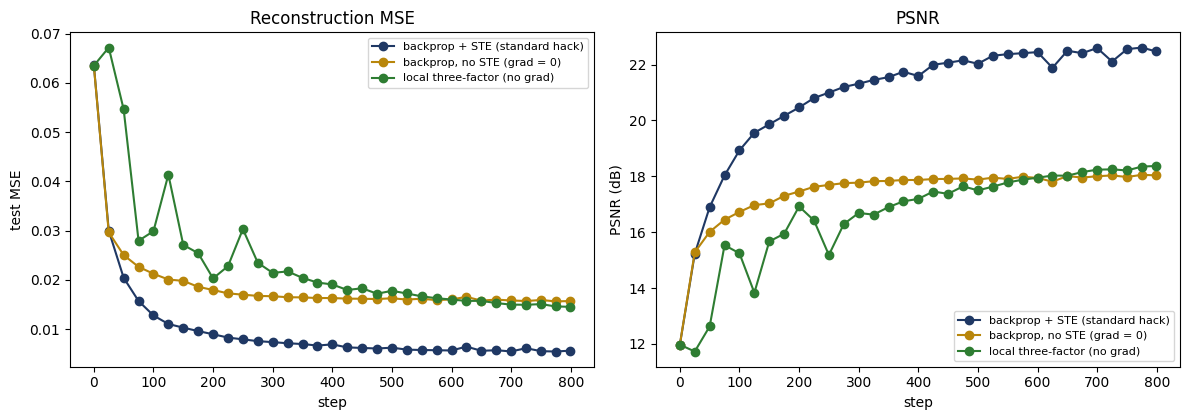

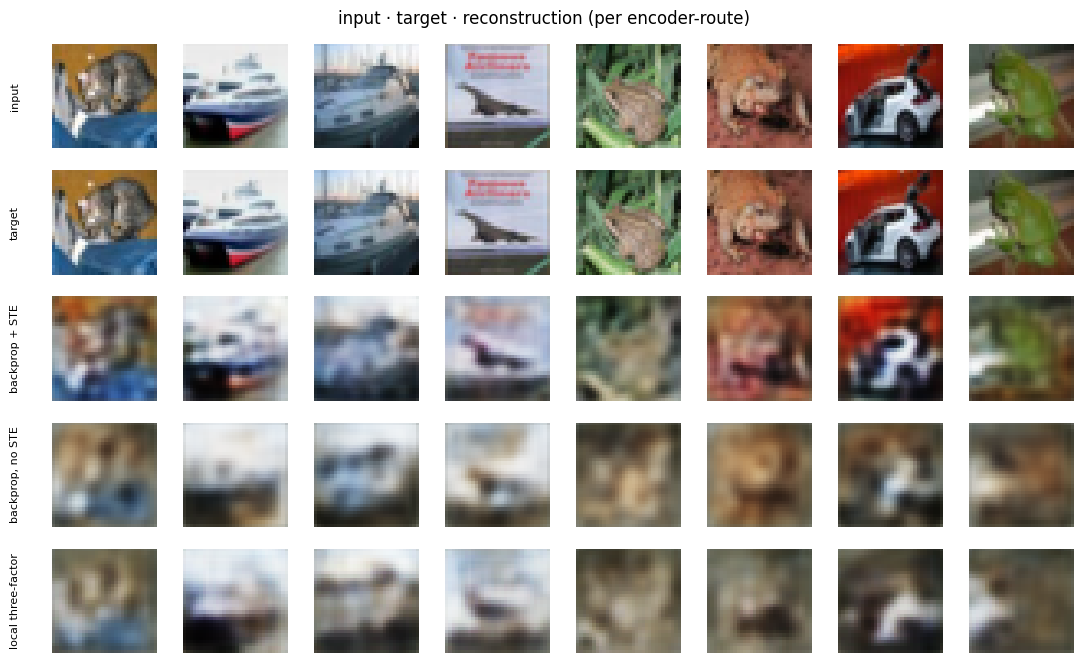

In [8]:
# Learning curves + reconstruction grids per method
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for k in ['ste','no_ste','local']:
    c = RES[k]['curve']; st=[r[0] for r in c]
    ax[0].plot(st, [r[1] for r in c], 'o-', color=CLR[k], label=LAB[k])
    ax[1].plot(st, [r[2] for r in c], 'o-', color=CLR[k], label=LAB[k])
ax[0].set_xlabel('step'); ax[0].set_ylabel('test MSE'); ax[0].set_title('Reconstruction MSE'); ax[0].legend(fontsize=8)
ax[1].set_xlabel('step'); ax[1].set_ylabel('PSNR (dB)'); ax[1].set_title('PSNR'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# input | target | reconstruction (RGB), per method
xte = Xte[:8]; xin = corrupt_in(xte)
rows = [('input', xin.detach()), ('target', xte.detach())]
for k in ['ste','no_ste','local']:
    with torch.no_grad(): rec = torch.sigmoid(RES[k]['model'](xin, ste=False)[0]).clamp(0, 1)
    rows.append((LAB[k].split(' (')[0], rec))
fig, ax = plt.subplots(len(rows), 8, figsize=(11, 1.35*len(rows)))
for r,(name,imgs) in enumerate(rows):
    for j in range(8):
        ax[r,j].imshow(imgs[j].permute(1,2,0).cpu().clamp(0,1).numpy()); ax[r,j].axis('off')
    ax[r,0].text(-0.35, 0.5, name, fontsize=8, rotation=90, va='center', ha='center', transform=ax[r,0].transAxes)
plt.suptitle('input · target · reconstruction (per encoder-route)'); plt.tight_layout(); plt.show()

## Probe-size sweep (the caveat)

In [9]:
# Honest caveat (the Step-4 plateau, VQ version): the probe size has a SWEET SPOT.
#   too small -> the antithetic points sit almost on top of each other in latent space: weak, high-variance signal.
#   too large -> each probe shoves z_e across many code cells at once and thrashes the EMA codebook -> it stops learning.
# We short-train the encoder (local rule) at several probe sizes and read the resulting reconstruction.
SWEEP_STEPS  = 6 if SMOKE else 120
SWEEP_SIGMAS = [0.05, 0.2] if SMOKE else [0.02, 0.05, 0.1, 0.2, 0.4]
_saveSIG = SIGMA
print(f'{"probe sigma":>12}{"final MSE":>12}{"final PSNR":>13}{"codebook ppl":>14}')
print('-'*51)
for sg in SWEEP_SIGMAS:
    SIGMA = sg
    torch.manual_seed(0); ms = VQVAE(D, K, HIDDEN).to(device); init_codebook(ms, Xtr)
    train_local(ms, Xtr, SWEEP_STEPS, record=[])
    mse, psnr, p = evaluate(ms, Xte)
    print(f'{sg:>12.3f}{mse:>12.4f}{psnr:>13.2f}{p:>14.1f}')
SIGMA = _saveSIG
print('\nSweet spot ~0.05 here (lowest MSE / best PSNR, healthy perplexity). Report this sweep alongside the headline --')
print('it is what makes the claim precise rather than a hand-wave.')

 probe sigma   final MSE   final PSNR  codebook ppl
---------------------------------------------------
       0.020      0.0288        15.40          33.0
       0.050      0.0533        12.73          10.7
       0.100      0.0425        13.71          12.5
       0.200      0.0702        11.54           3.0
       0.400      0.0389        14.10           9.1

Sweet spot ~0.05 here (lowest MSE / best PSNR, healthy perplexity). Report this sweep alongside the headline --
it is what makes the claim precise rather than a hand-wave.


## Latent DDPM — the generative payoff
With the VQ-VAE trained, a small denoising-diffusion model learns the distribution of the code latents. Sampling runs noise → latent DDPM → snap to codebook → decode, turning pure noise into CIFAR images — the full **VQ-latent diffusion** pipeline. (The DDPM denoiser is differentiable, so it trains by ordinary backprop; the non-differentiable part was only the VQ, handled above.)

  ddpm step     0  mse 1.0040
  ddpm step   400  mse 0.4357
  ddpm step   800  mse 0.4388
  ddpm step  1200  mse 0.3767
  ddpm step  1600  mse 0.4300


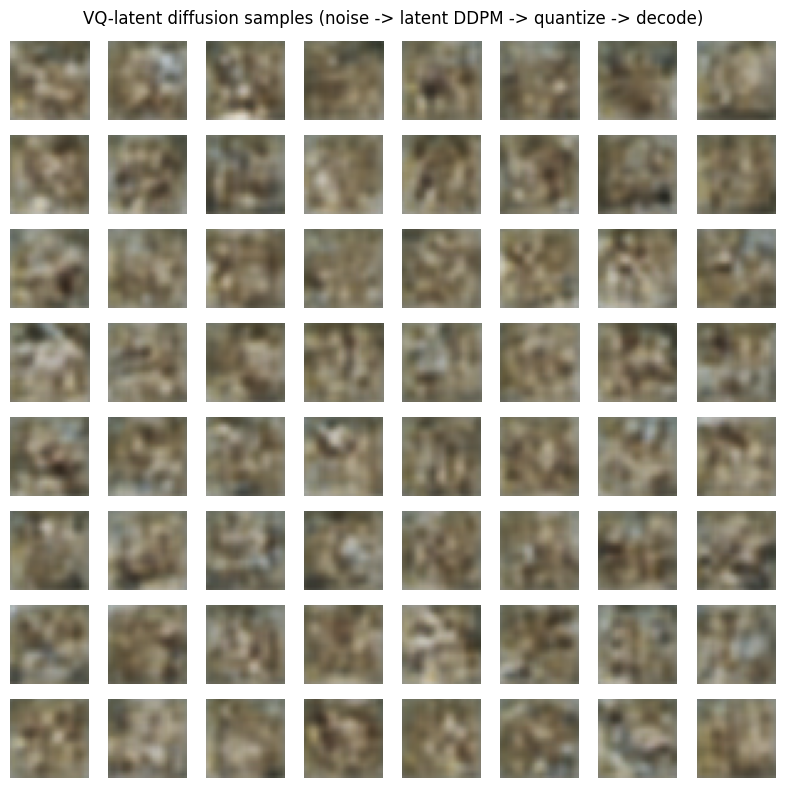

In [10]:
# ── Latent DDPM: train a small denoiser on the VQ latents, then sample CIFAR images from noise ──
# Uses the local-rule VQ-VAE (any trained model works). The DDPM denoiser is fully differentiable
# (no channel here) -> standard backprop. This is the generative payoff of "VQ-latent diffusion".
VQ = RES['local']['model']
with torch.no_grad():
    Z = VQ.encode(Xtr)                                   # (N, D, 8, 8) continuous latents
    zmu, zsd = Z.mean((0,2,3), keepdim=True), Z.std((0,2,3), keepdim=True) + 1e-5
    Zn = (Z - zmu) / zsd

class LatentDenoiser(nn.Module):
    def __init__(self, D, hid=64, temb=64):
        super().__init__(); self.temb = temb
        self.tmlp = nn.Sequential(nn.Linear(temb, hid), nn.SiLU(), nn.Linear(hid, hid))
        self.c1 = nn.Conv2d(D, hid, 3, 1, 1); self.c2 = nn.Conv2d(hid, hid, 3, 1, 1)
        self.c3 = nn.Conv2d(hid, hid, 3, 1, 1); self.out = nn.Conv2d(hid, D, 3, 1, 1)
    def temb_(self, t):
        half = self.temb//2
        fr = torch.exp(torch.linspace(0, -9, half, device=t.device))
        e = t[:, None].float()*fr[None]; return torch.cat([e.sin(), e.cos()], 1)
    def forward(self, z, t):
        tb = self.tmlp(self.temb_(t))[:, :, None, None]
        h = F.silu(self.c1(z) + tb); h = F.silu(self.c2(h) + tb); h = F.silu(self.c3(h) + tb)
        return self.out(h)

betas = torch.linspace(1e-4, 0.02, DDPM_T, device=device)
alphas = 1 - betas; abar = torch.cumprod(alphas, 0)
den = LatentDenoiser(D, DDPM_HID).to(device)
dopt = torch.optim.Adam(den.parameters(), lr=2e-3)
for s in range(DDPM_STEPS):
    z0 = Zn[torch.randint(0, len(Zn), (BATCH,))]
    t = torch.randint(0, DDPM_T, (z0.shape[0],), device=device)
    eps = torch.randn_like(z0)
    zt = abar[t][:,None,None,None].sqrt()*z0 + (1-abar[t])[:,None,None,None].sqrt()*eps
    loss = F.mse_loss(den(zt, t), eps)
    dopt.zero_grad(); loss.backward(); dopt.step()
    if s % max(1, DDPM_STEPS//5) == 0: print(f'  ddpm step {s:5d}  mse {loss.item():.4f}')

@torch.no_grad()
def sample(n=64):
    z = torch.randn(n, D, 8, 8, device=device)
    for ti in reversed(range(DDPM_T)):
        t = torch.full((n,), ti, device=device)
        eps = den(z, t)
        a, ab = alphas[ti], abar[ti]
        z = (z - (1-a)/(1-ab).sqrt()*eps) / a.sqrt()
        if ti > 0: z = z + betas[ti].sqrt()*torch.randn_like(z)
    z = z*zsd + zmu                                      # unnormalize
    zq, idx = VQ.quantize(z)                             # snap to codebook
    return torch.sigmoid(VQ.decode(zq)).clamp(0, 1)      # RGB in [0,1]

samp = sample(64)
fig, ax = plt.subplots(8, 8, figsize=(8, 8))
for i in range(64):
    ax[i//8, i%8].imshow(samp[i].permute(1,2,0).cpu().clamp(0,1).numpy()); ax[i//8, i%8].axis('off')
plt.suptitle('VQ-latent diffusion samples (noise -> latent DDPM -> quantize -> decode)'); plt.tight_layout(); plt.show()

## Honest caveat & cost
The local rule's advantage isn't free: (1) the **probe size has a sweet spot** (the sweep above) — too small gives a weak, high-variance signal; too large shoves the latents across many code cells at once and thrashes the EMA codebook — the VQ analogue of the quantization-step caveat; (2) at equal steps it spends `2·M` forward passes per step vs backprop's ~1, so it's compute-heavier — which is why the encoder is kept small (cost ∝ encoder P²). The claim is **possibility, not efficiency**: it trains the encoder where the exact backward pass gives literally nothing.

## How to read this
This is the *possibility, not degree* result on a real generative architecture. The no-STE row makes the trap explicit — the encoder gradient is exactly zero, so without the STE hack the encoder cannot learn at all. The local three-factor rule recovers most of the STE reconstruction while touching only the encoder and never differentiating the codebook. Numbers here are for a small model at few steps; scale the model and steps on an A100 for publication-grade curves.